# **Assignment 2: Bandits and Exploration/Exploitation**

In this notebook, you will:
- Learn how to create your first bandit algorithm
- Understand the effect of epsilon on exploration and learn about the exploration/exploitation tradeoff
- Be introducing to some of the reinforcement learning software we are going to use for this specialization

This notebook uses RL-Glue to implement most of experiments. It was originally designed by Adam White, Brian Tanner, and Rich Sutton. This library will give you a solid framework to understand how reinforcement learning experiments work and how to run your own.

## **Section 0: Preliminaries**

In [2]:
!unzip "Lab2-Bandits and Exploration - Exploitation.zip"

Archive:  Lab2-Bandits and Exploration - Exploitation.zip
   creating: Lab2-Bandits and Exploration - Exploitation/
  inflating: Lab2-Bandits and Exploration - Exploitation/Assignment2.ipynb  
  inflating: Lab2-Bandits and Exploration - Exploitation/main_agent.py  
   creating: Lab2-Bandits and Exploration - Exploitation/rlglue/
  inflating: Lab2-Bandits and Exploration - Exploitation/rlglue/agent.py  
  inflating: Lab2-Bandits and Exploration - Exploitation/rlglue/environment.py  
  inflating: Lab2-Bandits and Exploration - Exploitation/rlglue/rl_glue.py  
  inflating: Lab2-Bandits and Exploration - Exploitation/ten_arm_env.py  


In [5]:
import os
os.chdir("/content/Lab2-Bandits and Exploration - Exploitation")
print("cwd:", os.getcwd())
print(os.listdir("."))


cwd: /content/Lab2-Bandits and Exploration - Exploitation
['ten_arm_env.py', 'rlglue', 'main_agent.py', 'Assignment2.ipynb']


In [6]:
#---------------------------
# Import necessary libraries
#---------------------------
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from rlglue.rl_glue import RLGlue
import main_agent
import ten_arm_env

You might have noticed that we import ten_arm_env. This is the __10-armed Testbed__ introduced in the textbook. We use this throughout this notebook to test our bandit agents. It has 10 arms, which are the actions the agent can take. Pulling an arm generates a stochastic reward from a Gaussian distribution with unit-variance. For each action, the expected value of that action is randomly sampled from a normal distribution, at the start of each run. If you are unfamiliar with the 10-armed Testbed please review it in the textbook before continuing.

## **Section 1: Greedy Agent**

We want to create an agent that will find the action with the highest expected reward. One way an agent could operate is to always choose the action with  the highest value based on the agent’s current estimates. This is called a greedy agent as it greedily chooses the action that it thinks has the highest value. Let's look at what happens in this case.

First we are going to implement the argmax function, which takes in a list of action values and returns an action with the highest value. Why are we implementing our own instead of using the argmax function that numpy uses? Numpy's argmax function returns the first instance of the highest value. We do not want that to happen as it biases the agent to choose a specific action in the case of ties. Instead we want to break ties between the highest values randomly. So we are going to implement our own argmax function. You may want to look at [np.random.choice](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.choice.html) to randomly select from a list of values.

In [7]:
#---------------------------------------------------------------------------
# Function to find the index of the maximum Q-Value with tie-breaking
#---------------------------------------------------------------------------
def argmax(q_values):
    """
    Finds and returns the index of the highest value in a list of q_values.
    If multiple indices have the highest value (a tie), one is selected randomly.

    Parameters:
    q_values (list): A list of numerical values representing Q-values.

    Returns:
    int: The index of the maximum value in q_values. If there are multiple,
         a random index from the tied values is selected.
    """

    top_value = float("-inf")
    ties = []

    for i in range(len(q_values)):
        # Check if the current value is greater than the highest recorded value
        if q_values[i] > top_value:
            top_value = q_values[i]
            ties = [i]

        # If the current value equals the highest value, add its index to ties
        elif q_values[i] == top_value:
            ties.append(i)

    random_select = np.random.choice(ties)
    return random_select

In [8]:
# --------------------------------------------
# Tests for the argmax function
# --------------------------------------------

# The highest value (1) appears at index 8.
test_array = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
assert argmax(test_array) == 8, "Error: argmax should return index 8 for this test case."

# The highest value (1) appears at indices 0 and 3.
# We set a random seed to ensure consistent results for testing.
np.random.seed(0)
test_array = [1, 0, 0, 1]
assert argmax(test_array) == 0, "Error: With seed 0, argmax should return index 0."

print("All tests passed successfully!")

All tests passed successfully!


Now we introduce the first part of an RL-Glue agent that you will implement. Here we are going to create a GreedyAgent and implement the agent_step method. This method gets called each time the agent takes a step. The method has to return the action selected by the agent. This method also ensures the agent’s estimates are updated based on the signals it gets from the environment.

Fill in the code below to implement a greedy agent.

In [9]:
# -------------------------------------------------
# GreedyAgent: A greedy reinforcement learning agent
# -------------------------------------------------

class GreedyAgent(main_agent.Agent):
    """
    A greedy agent that selects actions based on the highest estimated value (Q-value).
    It updates its Q-values using an incremental update rule based on received rewards.
    """

    def agent_step(self, t, reward, observation=None):
        """
        Executes one step in the agent's decision process.

        Parameters:
        t (int): The current time step.
        reward (float): The reward received from the environment after the last action.
        observation (float, optional): The observed state of the environment.

        Returns:
        int: The action chosen by the agent at the current time step.
        """

        ### Class Variables for Reference ###
        # self.q_values : A list storing the estimated value of each action (arm).
        # self.arm_count : A list tracking the number of times each action has been selected.
        # self.last_action : The index of the action taken in the previous time step.
        #####################################

        # Step 1: Update the count for the previously taken action
        self.arm_count[self.last_action] += 1

        # Step 2: Compute the step size for updating Q-values (1/n)
        alpha = 1.0 / self.arm_count[self.last_action]

        # Step 3: Incremental update for Q-values
        self.q_values[self.last_action] += alpha * (reward - self.q_values[self.last_action])

        # Step 4: Greedy action selection
        current_action = argmax(self.q_values)

        # Step 5: Store chosen action
        self.last_action = current_action

        return current_action

Let's visualize the result. Here we run an experiment using RL-Glue to test our agent. For now, we will set up the experiment code; in future lessons, we will walk you through running experiments so that you can create your own.

100%|██████████| 200/200 [00:05<00:00, 33.80it/s]


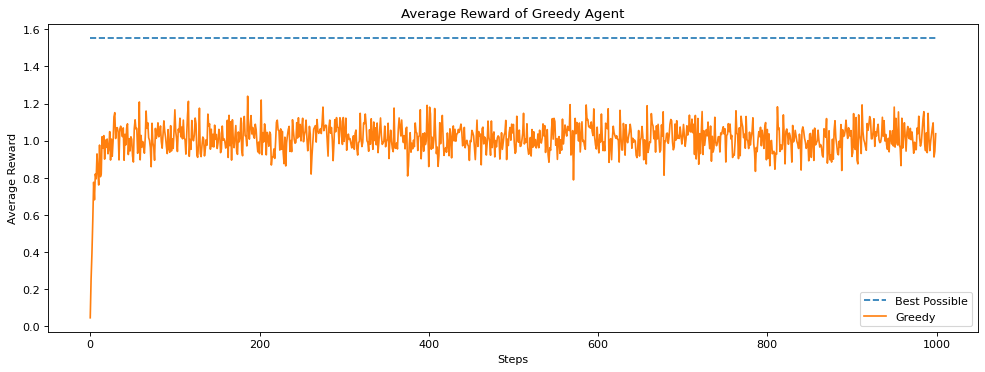

In [18]:
# -----------------------------------------------------------
# Experiment: evaluating the performance of a greedy agent
# -----------------------------------------------------------

# Experiment settings
num_runs = 200                    # The number of independent experiment runs
num_steps = 1000                  # The number of actions taken in each run

# Environment and agent selection
env = ten_arm_env.Environment      # Choosing the 10-armed bandit environment
agent = GreedyAgent                # Selecting the greedy agent for evaluation

# Configuration settings for the agent and environment
agent_info = {"num_actions": 10}   # Passing the number of arms to the agent
env_info = {}                      # No additional parameters needed for the environment

# Initializing reward tracking
rewards = np.zeros((num_runs, num_steps))  # Stores rewards for each run at each step
average_best = 0  # Tracks the average optimal reward across runs

# Running multiple independent experiments
for run in tqdm(range(num_runs)):
    np.random.seed(run)

    # Initialize the RLGlue framework with the selected environment and agent
    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # Track the best possible action's reward for comparison
    average_best += np.max(rl_glue.environment.arms)

    # Run the experiment for the defined number of steps
    for i in range(num_steps):
        # Take a step in the environment and get feedback
        step_result = rl_glue.rl_step(i)
        reward = step_result[0]

        # Store the received reward
        rewards[run, i] = reward


# Compute the average reward across all runs
greedy_scores = np.mean(rewards, axis=0)

# Visualization of results
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([average_best / num_runs for _ in range(num_steps)], linestyle="--")
plt.plot(greedy_scores)
plt.legend(["Best Possible", "Greedy"])
plt.title("Average Reward of Greedy Agent")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()

**How did our agent do? Is it possible for it to do better?**

## Greedy Agent Performance

The greedy agent improves quickly at the beginning, but its average reward stabilizes well below the “Best Possible” line (the expected reward of the optimal arm $( max_a q^*(a) )$.

This happens because rewards are stochastic, so early random outcomes can make a suboptimal arm look best. Since the greedy agent performs no exploration, it keeps exploiting that arm and may never discover the true optimal one.

### How did the agent do?
The agent improved compared to random selection, but it did not reach optimal performance.

### Is it possible for it to do better?
Yes. Introducing exploration (e.g., using an ε-greedy strategy) would allow the agent to try other arms and increase the probability of identifying the true optimal arm, leading to higher long-term average reward.


## **Section 2: Epsilon-Greedy Agent**

We learned about another way for an agent to operate, where it does not always take the greedy action. Instead, sometimes it takes an exploratory action. It does this so that it can find out what the best action really is. If we always choose what we think is the current best action is, we may miss out on taking the true best action, because we haven't explored enough times to find that best action.

Implement an epsilon-greedy agent below. You may want to use your greedy code from above and look at [np.random.random](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.random.html), as well as [np.random.randint](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randint.html), to help you select random actions.

In [19]:
# ----------------------------------------------------------
# Epsilon-Greedy agent: balancing exploration & exploitation
# ----------------------------------------------------------

class EpsilonGreedyAgent(main_agent.Agent):
    """
    An epsilon-greedy agent that balances exploration and exploitation.
    It updates its Q-values based on received rewards and selects actions
    either greedily (most rewarding) or randomly (exploration) based on epsilon.
    """

    def agent_step(self, t, reward, observation):
        """
        Executes one step in the agent's decision-making process.

        Parameters:
        t (int): The current time step.
        reward (float): The reward received from the environment after the last action.
        observation (float, optional): The observed state of the environment.

        Returns:
        int: The action chosen by the agent at the current time step.
        """

        ### Class Variables for Reference ###
        # self.q_values : A list storing the estimated value of each action (arm).
        # self.arm_count : A list tracking the number of times each action has been selected.
        # self.last_action : The index of the action taken in the previous time step.
        # self.epsilon : Probability of selecting a random action (exploration factor).
        #####################################

        # YOUR CODE HERE

        # Step 1: Update Q-values using an incremental update rule
        # Update the count for the previously taken action

        self.arm_count[self.last_action] += 1

        # Step-size for sample-average update: alpha = 1 / N(a)
        alpha = 1.0 / self.arm_count[self.last_action]

        # Incremental update:
        # Q(a) <- Q(a) + alpha * (reward - Q(a))
        self.q_values[self.last_action] += alpha * (reward - self.q_values[self.last_action])

        # --- 2) Choose next action (epsilon-greedy) ---
        if np.random.rand() < self.epsilon:
            # Explore: random action
            current_action = np.random.choice(self.num_actions)
        else:
            # Exploit: greedy action (with tie-breaking)
            current_action = argmax(self.q_values)

        # --- 3) Store action for next update ---
        self.last_action = current_action
        return current_action

Now that we have our epsilon greedy agent created. Let's compare it against the greedy agent with epsilon of 0.1.

100%|██████████| 200/200 [00:06<00:00, 32.69it/s]


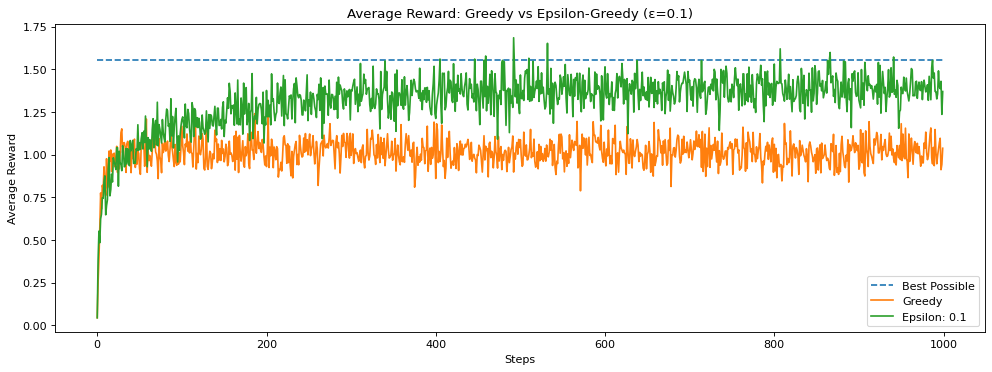

In [20]:
# -----------------------------------------------------------
# Comparing greedy and epsilon-greedy agent performance
# -----------------------------------------------------------

# Experiment settings
num_runs = 200                    # Number of independent experiment runs
num_steps = 1000                  # Number of actions taken in each run
epsilon = 0.1                     # Exploration probability for the epsilon-greedy agent

# Environment and agent selection
agent = EpsilonGreedyAgent
env = ten_arm_env.Environment

# Configuration settings for the agent and environment
agent_info = {"num_actions": 10, "epsilon": epsilon}
env_info = {}

# Initializing reward tracking
all_rewards = np.zeros((num_runs, num_steps))  # Stores rewards for each run at each step
average_best = 0
# Running multiple independent experiments
for run in tqdm(range(num_runs)):
    np.random.seed(run)

    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # true best expected reward in this run
    average_best += np.max(rl_glue.environment.arms)

    for i in range(num_steps):
        reward = rl_glue.rl_step(i)[0]
        all_rewards[run, i] = reward

epsilon_greedy_scores = np.mean(all_rewards, axis=0)
best_line = [average_best / num_runs] * num_steps

plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot(best_line, linestyle="--")
plt.plot(greedy_scores)               # from previous greedy experiment
plt.plot(epsilon_greedy_scores)
plt.title("Average Reward: Greedy vs Epsilon-Greedy (ε=0.1)")
plt.legend(("Best Possible", "Greedy", "Epsilon: 0.1"))
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()

**Why does the epsilon-greedy strategy often lead to better long-term performance in reinforcement learning?**

## Greedy vs Epsilon-Greedy Performance

In this experiment, we compared the purely greedy agent with an ε-greedy agent (ε = 0.1).

The ε-greedy agent achieves a higher long-term average reward than the greedy agent. Although it may perform slightly worse in the very early steps due to random exploration, it eventually surpasses the greedy strategy.

### Why does ε-greedy perform better?

The greedy agent does not explore and can become stuck exploiting a suboptimal arm if early noisy rewards are misleading. In contrast, the ε-greedy agent selects a random action with probability ε, which allows it to continue sampling other arms. This ongoing exploration increases the probability of discovering the true optimal arm.

As a result, ε-greedy balances exploration and exploitation more effectively and achieves better long-term performance across runs.


### **Section 2.1 Averaging Multiple Runs**

Did you notice that we averaged over 200 runs? Why did we do that?

To get some insight, let's look at the results of two individual runs by the same agent.

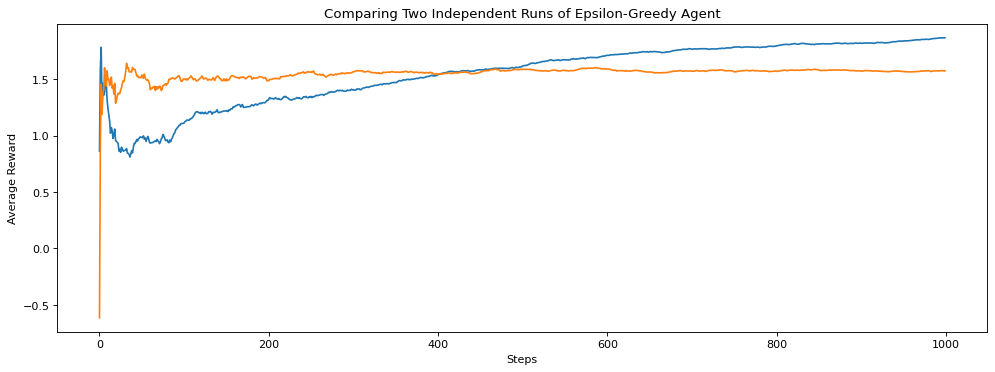

In [22]:
# -------------------------------------------------------------
# Visualizing two independent runs of the epsilon-greedy agent
# -------------------------------------------------------------

# Select the agent and environment for the experiment
agent = EpsilonGreedyAgent
env = ten_arm_env.Environment

# Define agent and environment configurations
agent_info = {"num_actions": 10, "epsilon": 0.1}
env_info = {}

# Set up the figure for plotting results
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

# Number of steps each agent takes
num_steps = 1000

# Run the experiment twice with different random seeds to compare behaviors
for run in (0, 1):
    np.random.seed(run)  # Set seed to compare the behavior across different runs
    averages = []  # Track average rewards over time

    # Initialize the RLGlue framework with the selected environment and agent
    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # Track cumulative rewards
    scores = [0]

    for i in range(num_steps):
        # Take a step and get the reward
        step_result = rl_glue.rl_step(i)
        reward = step_result[0]

        # Update cumulative reward
        scores.append(scores[-1] + reward)

        # Compute running average reward
        averages.append(scores[-1] / (i + 1))


    # Plot the average rewards over time for this run
    plt.plot(averages)

# Add title, labels, and legend to the plot
plt.title("Comparing Two Independent Runs of Epsilon-Greedy Agent")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()

**Notice how the two runs were different? But, if this is the exact same algorithm, why does it behave differently in these two runs?**

Even though both curves use the same ε-greedy algorithm, they behave differently because the problem is random.

In each run:
- The true values of the arms are randomly generated.
- The rewards include random noise.
- The ε-greedy agent sometimes explores randomly.

Because of this randomness, the agent may receive different rewards in the early steps. If early rewards make one arm look good in one run, the agent may start exploiting it more. In another run, a different arm might look better at the beginning.

These small differences at the start can lead to different learning paths. This is why we average results over many runs — a single run does not show the true expected performance of the algorithm.


The following script shows how setting different random seeds affects the agent's behavior. Specifically, it determines whether the agent takes an exploratory action based on a 10% probability.

In [23]:
# -----------------------------------------------------------
# Demonstrating the effect of random seeds on exploration
# -----------------------------------------------------------

# First run with Random Seed 1
print("Random Seed 1")
np.random.seed(1)  # Set seed for reproducibility
for _ in range(15):  # Loop for 15 time steps
    if np.random.random() < 0.1:  # 10% chance to take an exploratory action
        print("Exploratory Action")  # Print if exploration occurs

print("\n")

# Second run with Random Seed 2
print("Random Seed 2")
np.random.seed(2)  # Set a different seed to observe changes
for _ in range(15):  # Again, loop for 15 time steps
    if np.random.random() < 0.1:  # 10% chance for exploration
        print("Exploratory Action")  # Print if exploration occurs


Random Seed 1
Exploratory Action
Exploratory Action
Exploratory Action


Random Seed 2
Exploratory Action


With the first seed, we take an exploratory action three times out of 15, but with the second, we only take an exploratory action once. This can significantly affect the performance of our agent because the amount of exploration has changed significantly.

To compare algorithms, we therefore report performance averaged across many runs. We do this to ensure that we are not simply reporting a result that is due to stochasticity. Rather, we want statistically significant outcomes. We will not use statistical significance tests. Instead, because we have access to simulators for our experiments, we use the simpler strategy of running for a large number of runs and ensuring that the confidence intervals do not overlap.

## **Section 3: Comparing values of epsilon**

Can we do better than an epsilon of 0.1? Let's try several different values for epsilon and see how they perform. We try different settings of key performance parameters to understand how the agent might perform under different conditions.

Below we run an experiment to show how different values of epsilon (exploration rate) affect the performance of an epsilon-greedy agent in a multi-armed bandit problem. The results are plotted to show the average rewards over time.

100%|██████████| 200/200 [00:05<00:00, 33.74it/s]


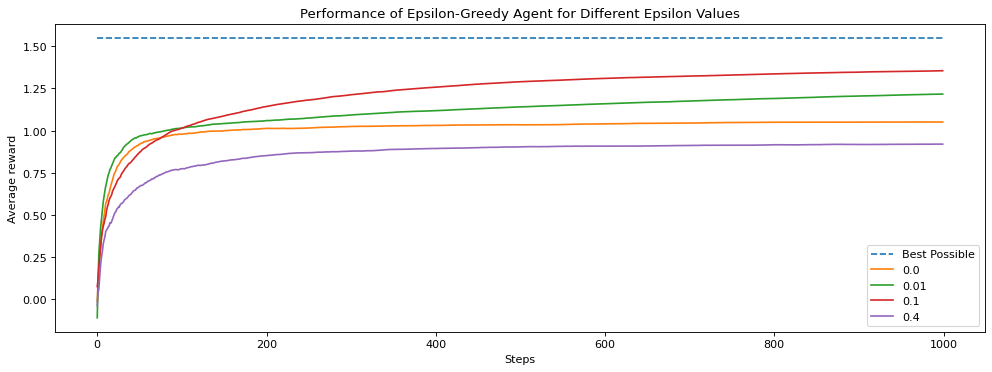

In [25]:
# ------------------------------------------------------------------------
# Comparing different epsilon values in the epsilon-greedy algorithm
# ------------------------------------------------------------------------

# Define different epsilon values to test
epsilons = [0.0, 0.01, 0.1, 0.4]  # 0.0 (greedy), small exploration (0.01), moderate (0.1), high (0.4)

# Set up the figure for plotting
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

# Plot the optimal possible reward as a reference (dashed line)
plt.plot([1.55 for _ in range(num_steps)], linestyle="--")

# Initialize lists to store results
n_q_values = []         # Stores Q-values for epsilon = 0.1 (for later analysis)
n_averages = []         # Stores average rewards for epsilon = 0.1
n_best_actions = []     # Tracks best action selections for epsilon = 0.1

num_runs = 200  # Number of independent experiment runs

# Iterate through each epsilon value and evaluate performance
for epsilon in epsilons:
    all_averages = []  # Store average rewards for all runs

    for run in tqdm(range(num_runs)):  # Progress bar for experiment runs
        agent = EpsilonGreedyAgent  # Use epsilon-greedy agent
        agent_info = {"num_actions": 10, "epsilon": epsilon}  # Set agent parameters
        env_info = {"random_seed": run}  # Set environment random seed for reproducibility

        # Initialize the RLGlue framework
        rl_glue = RLGlue(env, agent)
        rl_glue.rl_init(agent_info, env_info)
        rl_glue.rl_start()

        best_arm = np.argmax(rl_glue.environment.arms)  # Identify the best possible action

        # Initialize tracking variables
        scores = [0]                # Cumulative rewards
        averages = []               # Running average of rewards
        best_action_chosen = []     # Tracks if the best action was chosen

        for i in range(num_steps):
            # Take a step in the environment and receive feedback
            step_result = rl_glue.rl_step(i)
            reward = step_result[0]

            # Update cumulative rewards
            scores.append(scores[-1] + reward)
            averages.append(scores[-1] / (i + 1))

            # Track if the best action was chosen
            best_action_chosen.append(1 if rl_glue.agent.last_action == best_arm else 0)

            # Store Q-values for detailed analysis if epsilon = 0.1 and run = 0
            if epsilon == 0.1 and run == 0:
                n_q_values.append(np.copy(rl_glue.agent.q_values))

        # Store averages and best action tracking for epsilon = 0.1
        if epsilon == 0.1:
            n_averages = averages
            n_best_actions = best_action_chosen


        all_averages.append(averages)  # Store results for this epsilon value

    # Plot the mean performance of this epsilon value across all runs
    plt.plot(np.mean(all_averages, axis=0))

plt.legend(["Best Possible"] + epsilons)
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("Performance of Epsilon-Greedy Agent for Different Epsilon Values")
plt.show()

**Why did 0.1 perform better than 0.01? If exploration helps why did 0.4 perform worse than 0.0 (the greedy agent)?**

## Effect of Different Epsilon Values

From the plot, we can see that ε = 0.1 achieves the highest long-term average reward.
The greedy agent (ε = 0.0) performs worse, and ε = 0.4 performs the worst overall.

### Why did ε = 0.1 perform better than ε = 0.01?

Both values allow exploration, but ε = 0.01 explores very rarely.
This means the agent may not try enough different arms to reliably discover the true best one.
With ε = 0.1, the agent explores more often, which increases the chance of finding the optimal arm and correcting early mistakes.
This leads to better long-term performance.

### Why did ε = 0.4 perform worse than greedy?

Exploration helps, but too much exploration is harmful.
With ε = 0.4, the agent chooses a random arm 40% of the time.
Even after finding a good arm, it keeps exploring too much and often selects bad arms.
As a result, the average reward stays low.

In conclusion, there is a balance between exploration and exploitation.
Too little exploration (ε = 0.01 or 0.0) may lead to getting stuck, while too much exploration (ε = 0.4) prevents the agent from fully exploiting good actions.
In this experiment, ε = 0.1 provides the best balance.


## **Section 4: The effect of step size**

In Section 1 of this assignment, we decayed the step size over time based on action-selection counts. The step-size was 1/N(A), where N(A) is the number of times action A was selected. This is the same as computing a sample average. We could also set the step size to be a constant value, such as 0.1. What would be the effect of doing that? And is it better to use a constant or the sample average method?

To investigate this question, let’s start by creating a new agent that has a constant step size. This will be nearly identical to the agent created above. You will use the same code to select the epsilon-greedy action. You will change the update to have a constant step size instead of using the 1/N(A) update.

In [26]:
# ------------------------------------------------------------------------------
# Epsilon-Greedy agent with a constant step-size update rule
# ------------------------------------------------------------------------------
# This agent follows the epsilon-greedy strategy but updates its Q-values using
# a constant step size instead of computing an average from past rewards. This
# allows for a more stable learning process when dealing with non-stationary
# environments.
# ------------------------------------------------------------------------------

class EpsilonGreedyAgentConstantStepsize(main_agent.Agent):
    def agent_step(self, t, reward, observation=None):
        """
        Takes one step for the agent. It receives a reward and (optionally) an
        observation and returns the action the agent selects at this time step.

        Arguments:
        reward -- float, the reward received from the environment after taking
                  the previous action.
        observation -- float, the observed state of the agent (not used in this
                       implementation but included for future extensions).

        Returns:
        current_action -- int, the action chosen by the agent at the current
                          time step.
        """

        ### Useful Class Variables ###
        # self.q_values : An array storing the agent's estimated values for each action.
        # self.arm_count : An array tracking the number of times each action has been selected.
        # self.last_action : An integer representing the action the agent took in the previous step.
        # self.step_size : A constant float value determining how much the Q-values update.
        # self.epsilon : The probability of selecting a random action for exploration.
        ###############################

        # YOUR CODE HERE

        # Update count (optional but useful for diagnostics)
        self.arm_count[self.last_action] += 1

        # Constant step-size update
        self.q_values[self.last_action] += self.step_size * (reward - self.q_values[self.last_action])

        # Epsilon-greedy action choice
        if np.random.rand() < self.epsilon:
            current_action = np.random.choice(self.num_actions)
        else:
            current_action = argmax(self.q_values)

        self.last_action = current_action
        return current_action


        return current_action

Let's compare the performance of epsilon-greedy agents using different step size update rules. The step size controls how much each new reward influences the agent’s estimated Q-values.

**Step sizes tested**:
- 0.01, 0.1, 0.5, 1.0: Constant step sizes
- 1/N(A): Incremental averaging (1 divided by the number of times an action has been selected).

Note that performance is measured by tracking the percentage of times the agent selects the optimal action over 1000 steps, averaged over 200 independent runs.

<>:61: SyntaxWarning: invalid escape sequence '\e'
<>:61: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-1867175951.py:61: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Average Performance of $\epsilon$-Greedy Action-Value Methods for Different Step Sizes")
100%|██████████| 200/200 [00:07<00:00, 28.52it/s]
/tmp/ipython-input-1867175951.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])


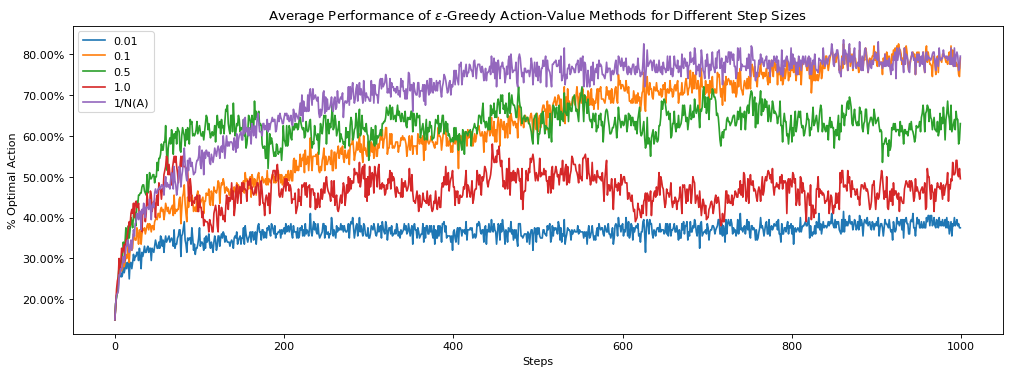

In [29]:
# -----------------------------------------------------------------------------------------
# Experiment: evaluating the performance of epsilon-greedy agents with different step sizes
# -----------------------------------------------------------------------------------------

step_sizes = [0.01, 0.1, 0.5, 1.0, '1/N(A)']  # Different step size strategies
epsilon = 0.1  # Probability of exploration
num_steps = 1000  # Number of steps per run
num_runs = 200  # Number of independent runs

# Initialize plot
fig, ax = plt.subplots(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

# Data structures for storing experiment results
q_values = {step_size: [] for step_size in step_sizes}  # Q-values per step size
true_values = {step_size: None for step_size in step_sizes}  # True values of each action
best_actions = {step_size: [] for step_size in step_sizes}  # Optimal action selections

# Run experiment for each step size
for step_size in step_sizes:
    all_averages = []  # Store average performance per run

    for run in tqdm(range(num_runs)):  # Iterate over multiple runs
        np.random.seed(run)  # Ensure reproducibility

        # Select the appropriate agent based on step size
        agent = EpsilonGreedyAgentConstantStepsize if step_size != '1/N(A)' else EpsilonGreedyAgent
        agent_info = {"num_actions": 10, "epsilon": epsilon, "step_size": step_size, "initial_value": 0.0}
        env_info = {}

        # Initialize RLGlue framework
        rl_glue = RLGlue(env, agent)
        rl_glue.rl_init(agent_info, env_info)
        rl_glue.rl_start()

        best_arm = np.argmax(rl_glue.environment.arms)  # Identify the optimal action

        if run == 0:
            true_values[step_size] = np.copy(rl_glue.environment.arms)  # Store true action values

        best_action_chosen = []  # Track if the optimal action was chosen

        for i in range(num_steps):
            # run the RL step function
            step_result = rl_glue.rl_step(i)

            # Check if the chosen action is the optimal one
            best_action_chosen.append(1 if rl_glue.agent.last_action == best_arm else 0)

            # Store Q-values for the first run
            if run == 0:
                q_values[step_size].append(np.copy(rl_glue.agent.q_values))


        best_actions[step_size].append(best_action_chosen)  # Store results for this run

    # Compute the average optimal action percentage over all runs and plot
    ax.plot(np.mean(best_actions[step_size], axis=0))

# Configure and display plot
plt.legend(step_sizes)
plt.title("Average Performance of $\epsilon$-Greedy Action-Value Methods for Different Step Sizes")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])
plt.show()

Notice first that we are now plotting the amount of time that the best action is taken rather than the average reward. To better  understand the performance of an agent, it can be useful to measure specific behaviors, beyond just how much reward is accumulated. This measure indicates how close the agent’s behaviour is to optimal.

**It seems as though 1/N(A) performed better than the others, in that it reaches a solution where it takes the best action most frequently. Now why might this be? Why did a step size of 0.5 start out better but end up performing worse? Why did a step size of 0.01 perform so poorly?**

## Effect of Step Size on Performance

In this experiment, we are measuring the percentage of time the agent selects the optimal action, instead of the average reward. This helps us understand how often the agent truly identifies and exploits the best arm.

From the plot, we see that the sample-average method (1/N(a)) performs best in the long run. It eventually selects the optimal action most frequently.

### Why did 1/N(a) perform better?

The sample-average update reduces the step size over time. As the agent gathers more data, the updates become smaller and more stable. In a stationary problem (where the true arm values do not change), this helps the estimates converge accurately to the true values. As a result, the agent reliably learns the optimal arm.

### Why did a step size of 0.5 start better but perform worse later?

A larger step size reacts strongly to new rewards. At the beginning, this helps the agent learn quickly. However, because rewards are noisy, a large step size also causes the estimates to fluctuate more. This makes learning unstable, so performance decreases in the long run.

### Why did a step size of 0.01 perform poorly?

A very small step size updates the estimates very slowly. This makes learning stable but extremely slow. The agent takes longer to correct mistakes or identify the best arm, so it performs worse overall within the given number of steps.

In summary, there is a trade-off: large step sizes learn quickly but are unstable, small step sizes are stable but slow, and the sample-average method works best in stationary environments because it converges over time.


### **Estimated values vs. Expected values**
So, the goal now is to observe how quickly and accurately different step sizes allow the agent to approximate the true value of the optimal action.

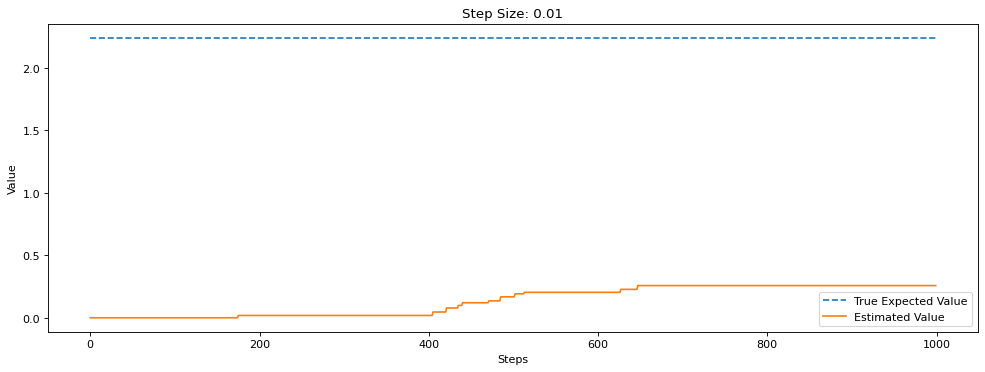

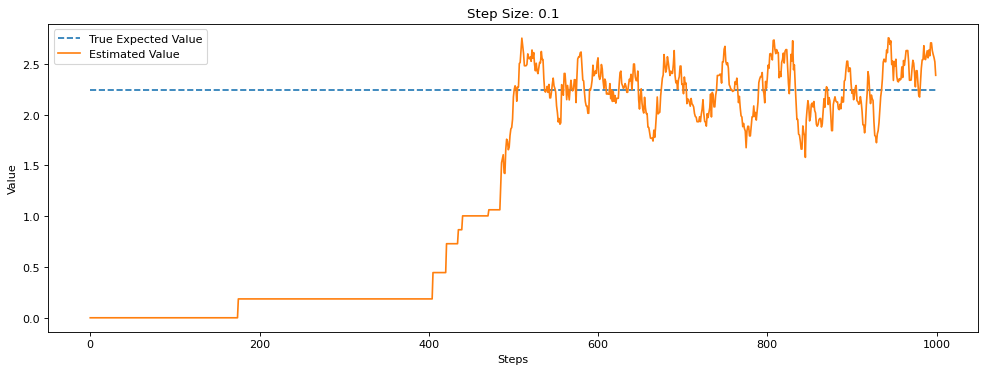

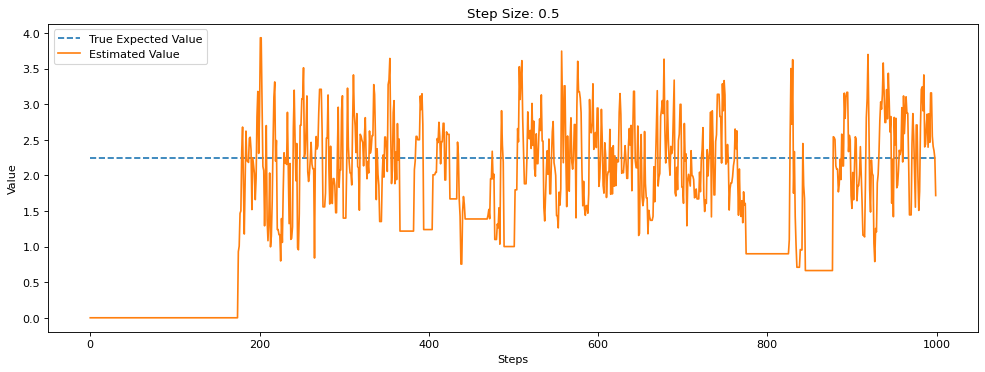

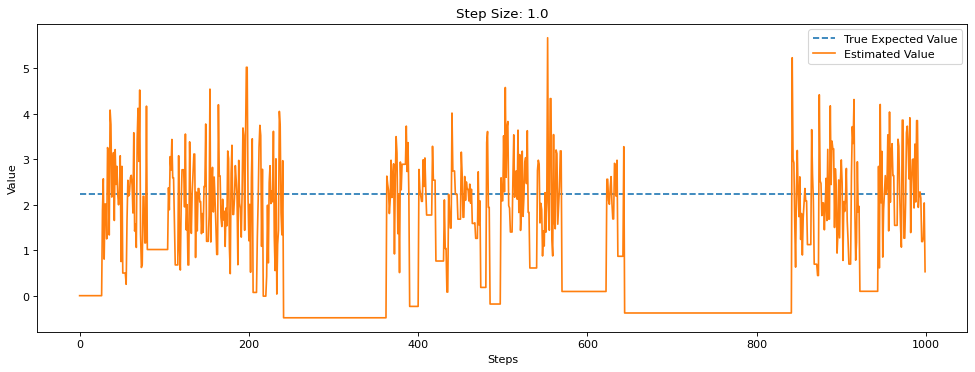

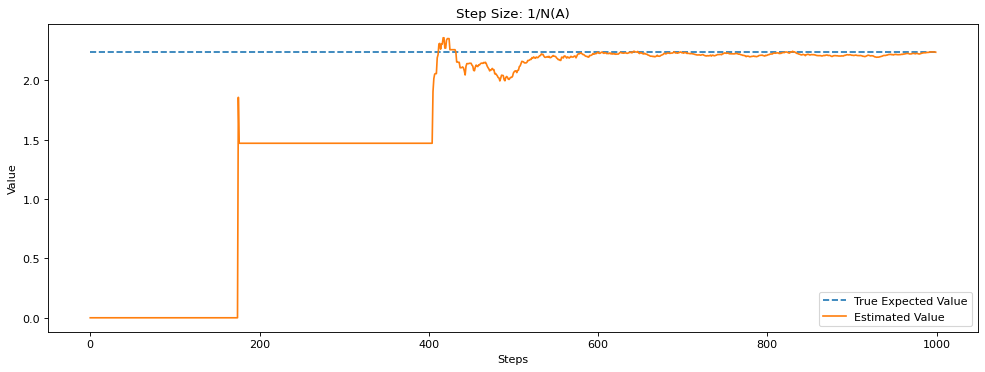

In [30]:
# --------------------------------------------------------------------------------
# Visualizing estimated Q-Values vs. true expected values for different step-sizes
# --------------------------------------------------------------------------------

largest = 0  # Index of the action with the highest true value
num_steps = 1000  # Number of steps in each run

# Iterate over each step size to generate a plot
for step_size in step_sizes:
    plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

    # Identify the action with the highest true expected value
    largest = np.argmax(true_values[step_size])


    # Plot the true expected value of the best action as a reference
    plt.plot([true_values[step_size][largest] for _ in range(num_steps)], linestyle="--", label="True Expected Value")

    # Plot the estimated Q-value of the best action over time
    plt.plot(np.array(q_values[step_size])[:, largest], label="Estimated Value")

    # Configure plot settings
    plt.title(f"Step Size: {step_size}")
    plt.xlabel("Steps")
    plt.ylabel("Value")
    plt.legend()

    # Show the plot
    plt.show()

These plots help clarify the performance differences between the different step sizes. A step size of 0.01 makes such small updates that the agent’s value estimate of the best action does not get close to the actual value. Step sizes of 0.5 and 1.0 both get close to the true value quickly, but are very susceptible to stochasticity in the rewards. The updates overcorrect too much towards recent rewards, and so oscillate around the true value. This means that on many steps, the action that pulls the best arm may seem worse than it actually is.  A step size of 0.1 updates fairly quickly to the true value, and does not oscillate as widely around the true values as 0.5 and 1.0. This is one of the reasons that 0.1 performs quite well. Finally we see why 1/N(A) performed well. Early on while the step size is still reasonably high it moves quickly to the true expected value, but as it gets pulled more its step size is reduced which makes it less susceptible to the stochasticity of the rewards.

**Does this mean that 1/N(A) is always the best? When might it not be?**

\## Is 1/N(a) Always the Best Step Size?

From the plots, 1/N(a) performs very well in this experiment. Its estimate becomes stable over time and converges close to the true expected value. This happens because the step size decreases as more samples are collected, which reduces the effect of reward noise and makes learning more accurate.

However, this does not mean that 1/N(a) is always the best choice.

The sample-average method works well in **stationary environments**, where the true action values do not change over time. In such cases, decreasing the step size helps the agent converge to the correct value.

But in a **non-stationary environment**, where the true values of the arms change over time, 1/N(a) can perform poorly. As the step size becomes very small, the agent stops adapting to new information. It gives too much importance to old rewards and reacts very slowly to changes.

In those cases, a **constant step size** (e.g., α = 0.1) is often better, because it keeps updating estimates at a steady rate and can adapt more quickly to changes in the environment.

In summary, 1/N(a) is best for stationary problems, but constant step sizes are better for non-stationary settings.


### **Non-stationary problems**
Let's look at how a sudden change in the reward distributions affects a step size like 1/N(A). This time we will run the environment for 2000 steps, and after 1000 steps we will randomly change the expected value of all of the arms. We compare two agents, both using epsilon-greedy with epsilon = 0.1. One uses a constant step size of 0.1, the other a step size of 1/N(A) that reduces over time.

100%|██████████| 500/500 [00:33<00:00, 14.97it/s]


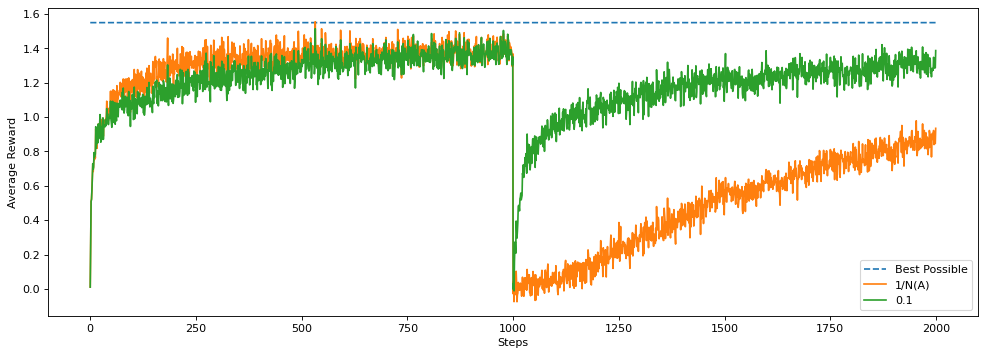

In [31]:
# ------------------------------------------------------------------------------
# Comparing standard and constant step-size epsilon-greedy agents over time
# ------------------------------------------------------------------------------
# This script evaluates two different epsilon-greedy agents:
# 1. EpsilonGreedyAgent (with 1/N(A) step size).
# 2. EpsilonGreedyAgentConstantStepsize (with a fixed step size of 0.1).
#
# The experiment runs each agent for multiple episodes and compares their
# performance based on average rewards over time. Additionally, at step 1000,
# the environment’s reward distribution shifts to test adaptability.
# ------------------------------------------------------------------------------

epsilon = 0.1         # Probability of exploration
num_steps = 2000      # Total number of steps per run
num_runs = 500        # Number of independent runs for averaging
step_size = 0.1       # Fixed step size for constant step-size agent

# Initialize the plot
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

# Plot the best possible reward as a reference
plt.plot([1.55 for _ in range(num_steps)], linestyle="--", label="Best Possible")

# Iterate over both agent types
for agent in [EpsilonGreedyAgent, EpsilonGreedyAgentConstantStepsize]:
    rewards = np.zeros((num_runs, num_steps))  # Store rewards for averaging

    # Run multiple experiments to get a stable average performance
    for run in tqdm(range(num_runs)):
        agent_info = {"num_actions": 10, "epsilon": epsilon, "step_size": step_size}
        np.random.seed(run)

        # Initialize the RL environment and agent
        rl_glue = RLGlue(env, agent)
        rl_glue.rl_init(agent_info, env_info)
        rl_glue.rl_start()

        for i in range(num_steps):
            # Take a step
            step_result = rl_glue.rl_step(i)
            reward = step_result[0]
            rewards[run, i] = reward

            # After 1000 steps, randomly change expected values of all arms
            if i == 999:  # after completing step 1000 (0-indexed)
                rl_glue.environment.arms = np.random.randn(10)


    # Plot the average rewards for each agent
    plt.plot(np.mean(rewards, axis=0), label="1/N(A)" if agent == EpsilonGreedyAgent else "0.1")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

**Now the agent with a step size of 1/N(A) performed better at the start but then performed worse when the environment changed! What happened?**

## Non-Stationary Environment Analysis

In this experiment, the true values of all arms change suddenly after 1000 steps. Before the change, the 1/N(a) step size performs better because it converges accurately to the true action values in the stationary setting.

However, after step 1000, the environment becomes different. The true rewards of the arms are no longer the same. At this point, the agent using 1/N(a) performs worse.

### What happened?

The sample-average method (1/N(a)) decreases its step size over time. As more samples are collected, the updates become very small. This works well when the environment is stationary, but after the sudden change, the agent cannot adapt quickly. It gives too much weight to old rewards and reacts very slowly to the new true values.

In contrast, the agent with a constant step size (α = 0.1) keeps updating its estimates at a steady rate. Even after 1000 steps, it still gives significant weight to new rewards. As a result, it adapts much faster to the new environment and recovers more quickly.

In summary, 1/N(a) works well in stationary problems, but in non-stationary environments a constant step size is better because it allows continuous adaptation.


## **Section 5: Upper-Confidence-Bound (UCB) Action Selection**

The **Upper-Confidence-Bound (UCB)** action selection method improves exploration by selecting actions based on their estimated value and an exploration bonus using the following formula:
  $$
  A_t = \arg\max_{a} \left( Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right)
  $$
  where:
  - \(Q_t(a)\) is the estimated value of action \(a\).
  - \(N_t(a)\) is the number of times action \(a\) has been selected.
  - \(t\) is the current time step.
  - \(c\) is a constant that controls exploration.

Complete the function that selects an action based on UCB.

In [32]:
# ------------------------------------------------------------------------------
# Upper Confidence Bound (UCB) agent implementation
# ------------------------------------------------------------------------------
# This agent follows the Upper Confidence Bound (UCB) action selection strategy,
# which balances exploration and exploitation by considering both the estimated
# value of each action and the uncertainty around that estimate.
#
# The agent selects actions based on:
#   Q(a) + c * sqrt( log(t + 1) / (N(a) + 1e-5) )
# where:
#   - Q(a) is the estimated value of action a.
#   - c (self.ucb_parameter) is a constant controlling exploration.
#   - t is the current time step.
#   - N(a) is the count of times action a has been taken.
#   - 1e-5 is a small constant to prevent division by zero.
# ------------------------------------------------------------------------------

class UCBAgent(main_agent.Agent):
    def agent_step(self, t, reward, observation=None):
        """
        Selects an action based on the Upper Confidence Bound (UCB) strategy.

        Arguments:
        t -- int, current time step.
        reward -- float, the reward received from the previous action.
        observation -- float, observed state (not used in this implementation).

        Returns:
        current_action -- int, the action selected by the agent.
        """

        # Ensure q_values and arm_count are NumPy arrays for efficient computation
        if isinstance(self.q_values, list):
            self.q_values = np.array(self.q_values)
        if isinstance(self.arm_count, list):
            self.arm_count = np.array(self.arm_count)

        # YOUR CODE HERE

        # Step 1: Update Q-values using an incremental update rule:
        # Q(a) ← Q(a) + (1/N(a)) * (reward - Q(a))
        self.arm_count[self.last_action] += 1
        alpha = 1.0 / self.arm_count[self.last_action]
        self.q_values[self.last_action] += alpha * (reward - self.q_values[self.last_action])


        # Step 2: Compute UCB Estimates
        # The agent selects actions based on the UCB formula:
        # Q(a) + ucb_parameter * sqrt(log(t + 1) / (N(a) + 1e-5))
        ucb_bonus = self.ucb_parameter * np.sqrt(np.log(t + 1) / (self.arm_count + 1e-5))
        ucb_estimates = self.q_values + ucb_bonus


        # Step 3: Select Action
        # Choose the action with the highest UCB estimate
        current_action = argmax(ucb_estimates)

        # Store the selected action for the next step
        self.last_action = current_action

        return current_action

The following experiment compares the performance of Epsilon-Greedy Agent (ε = 0.1) and Upper Confidence Bound (UCB) Agent (c = 2.0). The goal is to analyze how these two strategies perform over time in terms of the obtained average reward.

100%|██████████| 200/200 [00:11<00:00, 17.18it/s]


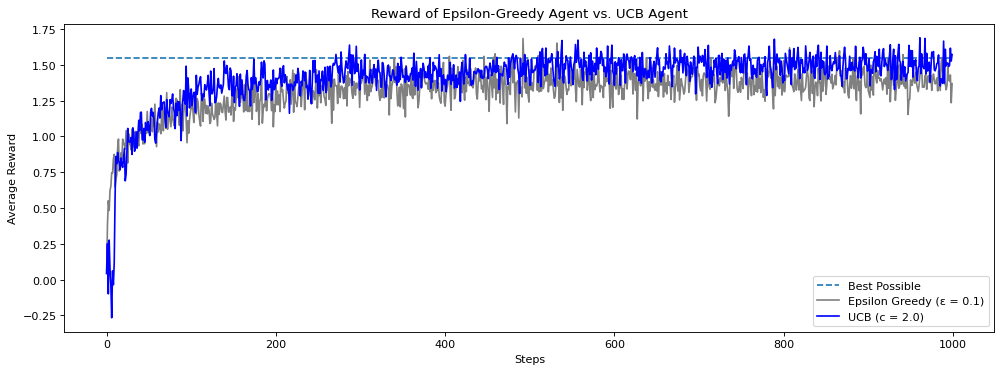

In [34]:
# ------------------------------------------------------------------------------
# Comparing epsilon-greedy and UCB agents
# ------------------------------------------------------------------------------

# Experiment Parameters
num_runs = 200         # Number of independent simulation runs
num_steps = 1000       # Number of time steps per run
epsilon = 0.1          # Exploration probability for epsilon-greedy agent
ucb_parameter = 2.0    # Exploration factor for UCB agent

# Define the agent and environment
agent = UCBAgent
env = ten_arm_env.Environment
agent_info = {"num_actions": 10, "epsilon": epsilon, "ucb_parameter": ucb_parameter}
env_info = {}

# Initialize array to store rewards for each run and step
all_rewards = np.zeros((num_runs, num_steps))

# Running Multiple Simulations
for run in tqdm(range(num_runs)):
    np.random.seed(run)

    # Initialize the RL environment and agent
    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # Simulate agent learning process
    for i in range(num_steps):
        step_result = rl_glue.rl_step(i)
        reward = step_result[0]
        all_rewards[run, i] = reward



# Compute the average reward across all runs for each time step
ucb_scores = np.mean(all_rewards, axis=0)

# Plot Results
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([1.55 for _ in range(num_steps)], linestyle="--", label="Best Possible")
plt.plot(epsilon_greedy_scores, color='grey', label=f"Epsilon Greedy (ε = {epsilon})")
plt.plot(ucb_scores, color='blue', label=f"UCB (c = {ucb_parameter})")
plt.title("Reward of Epsilon-Greedy Agent vs. UCB Agent")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

**How does the choice of the parameter $c$ affect the agent's performance? How does UCB compare to epsilon-greedy in terms of regret minimization?**

## UCB vs Epsilon-Greedy

From the plot, we see that UCB (with c = 2.0) achieves a slightly higher average reward than ε-greedy (ε = 0.1), especially in the long run.

### How does the parameter c affect performance?

The parameter c controls how much the agent explores.  
- If c is small, the agent explores less and behaves more like a greedy agent.  
- If c is large, the agent explores more aggressively.

A good value of c balances exploration and exploitation. If c is too large, the agent wastes time exploring suboptimal arms. If c is too small, it may not explore enough and can get stuck.

### How does UCB compare to ε-greedy in terms of regret?

UCB explores in a more intelligent way. Instead of choosing random actions (like ε-greedy), it selects actions based on both their estimated value and how uncertain they are. Arms that have been tried fewer times receive a higher exploration bonus.

Because of this, UCB tends to reduce regret more efficiently. It focuses exploration on uncertain arms rather than exploring completely at random. This usually leads to better long-term performance compared to ε-greedy.

In summary, UCB often performs better because it balances exploration and exploitation more systematically, leading to lower regret over time.


---



## **Section 6: Gradient Bandit Algorithm**
The **Gradient Bandit Algorithm** selects actions using a preference function, which is updated based on rewards received.

Implement a bandit agent that uses the **Gradient Bandit Algorithm** using the following update rules:
  $$
  H_t(a) \leftarrow H_t(a) + \alpha (R_t - \bar{R}_t) (1 - P_t(a))
  $$
  where:
  - $H_t(a)$ is the preference for action $a$.
  - $P_t(a)$ is the probability of selecting action $a$ (computed using a softmax function).
  - $\bar{R}_t$ is the running average of past rewards.
  - $\alpha$ is a step-size parameter.
- Compare the performance of the Gradient Bandit Algorithm with epsilon-greedy and UCB.
- Plot the action probabilities over time.

In [35]:
# ------------------------------------------------------------------------------
# Gradient bandit agent implementation
# ------------------------------------------------------------------------------
# This agent follows a gradient-based policy for selecting actions. Instead
# of maintaining direct value estimates for each action, it updates action
# preferences based on received rewards.
#
# Features:
# - Uses softmax action selection to determine probabilities.
# - Supports baseline reward subtraction for variance reduction.
# - Updates preferences using the policy gradient update rule.
# ------------------------------------------------------------------------------

class GradientBanditAgent(main_agent.Agent):
    def agent_step(self, t, reward, observation=None):
        """
        Executes a step for the Gradient Bandit Agent.

        Arguments:
        t -- int, current time step.
        reward -- float, reward received after taking the last action.
        observation -- float, observed state (not used in this implementation).

        Returns:
        current_action -- int, action chosen by the agent at this time step.
        """

        self.indices = np.arange(10)  # Array of action indices (0 to 9)

        # Ensure q_values and arm_count are NumPy arrays for efficient calculations
        if isinstance(self.q_values, list):
            self.q_values = np.array(self.q_values)
        if isinstance(self.arm_count, list):
            self.arm_count = np.array(self.arm_count)

        # YOUR CODE HERE

        # Step 1: Update average reward estimate (baseline)
        # incremental average of rewards
        self.average_reward += (reward - self.average_reward) / (t + 1)

        # Step 2: Preference update
        # Use baseline if enabled
        baseline = self.average_reward if self.gradient_baseline else 0.0

        # Softmax over preferences (compute current policy probs)
        prefs = self.q_values
        exp_prefs = np.exp(prefs - np.max(prefs))
        self.action_prob = exp_prefs / np.sum(exp_prefs)

        # Update preferences for all actions
        for a in self.indices:
            if a == self.last_action:
                self.q_values[a] += self.step_size * (reward - baseline) * (1 - self.action_prob[a])
            else:
                self.q_values[a] -= self.step_size * (reward - baseline) * (self.action_prob[a])

        # Step 3: Recompute action probabilities (after update)
        exp_prefs = np.exp(self.q_values - np.max(self.q_values))
        self.action_prob = exp_prefs / np.sum(exp_prefs)

        # Step 4: Sample an action from the softmax policy
        current_action = np.random.choice(self.indices, p=self.action_prob)

        self.last_action = current_action
        return current_action

This experiment evaluates the Gradient Bandit Algorithm on a 10-armed testbed when the $q^*(a)$ are chosen to be near $+4$ rather than near zero. We analyze performance across different step sizes $(α)$ and with/without baseline rewards. The baseline helps reduce variance, leading to more stable learning.

Running step_size=0.4, baseline=False: 100%|██████████| 500/500 [00:41<00:00, 12.19it/s]
/tmp/ipython-input-1781281354.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])


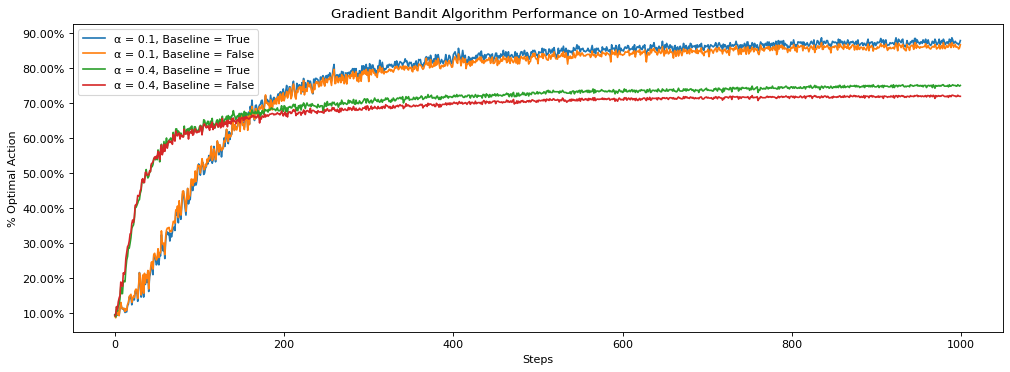

In [36]:
# ------------------------------------------------------------------------------------------------
# Experiment: gradient bandit algorithm with different step-sizes and baselines
# ------------------------------------------------------------------------------------------------

# Step sizes (α) and Baseline Variants to test
step_sizes = [0.1, 0.4]  # Learning rates for updating action preferences
gradient_baselines = [True, False]  # Whether to use a baseline reward estimate

# Experiment parameters
num_runs = 500  # Number of independent runs for averaging
num_steps = 1000  # Number of steps per run
all_rewards = np.zeros((num_runs, num_steps))  # To store reward values

# Data storage for analysis
q_values = {step_size: [] for step_size in step_sizes}  # Estimated preferences for each step size
true_values = {step_size: None for step_size in step_sizes}  # Ground-truth action values
best_actions = {step_size: [] for step_size in step_sizes}  # Optimal action selection tracking
legends = []  # Legends for the plot

# Initialize plot
fig, ax = plt.subplots(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

# Run the experiment for each step size and baseline combination
for step_size in step_sizes:
    for gradient_baseline in gradient_baselines:
        all_averages = []

        # Run multiple independent trials
        for run in tqdm(range(num_runs), desc=f"Running step_size={step_size}, baseline={gradient_baseline}"):
            np.random.seed(run)

            agent = GradientBanditAgent
            env = ten_arm_env.Environment
            agent_info = {
                "num_actions": 10,
                "step_size": step_size,
                "gradient_baseline": gradient_baseline,
                "initial_value": 0.0
            }
            env_info = {}

            rl_glue = RLGlue(env, agent)
            rl_glue.rl_init(agent_info, env_info)
            rl_glue.rl_start()

            best_arm = np.argmax(rl_glue.environment.arms)

            if run == 0:
                true_values[step_size] = np.copy(rl_glue.environment.arms)

            best_action_chosen = []
            for i in range(num_steps):
                step_result = rl_glue.rl_step(i)

                # Record whether the best action was taken
                best_action_chosen.append(1 if rl_glue.agent.last_action == best_arm else 0)

                # Store preference estimates for the first run
                if run == 0:
                    q_values[step_size].append(np.copy(rl_glue.agent.q_values))

            best_actions[step_size].append(best_action_chosen)

        legend_text = f"α = {step_size}, Baseline = {gradient_baseline}"
        legends.append(legend_text)
        ax.plot(np.mean(best_actions[step_size], axis=0), label=legend_text)



plt.legend()
plt.title("Gradient Bandit Algorithm Performance on 10-Armed Testbed")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])
plt.show()

**How does the step-size $\alpha$ affect the convergence of the Gradient Bandit Algorithm? Does the algorithm perform better in non-stationary environments?**

## Gradient Bandit Algorithm

From the plot, we can see that the step size α affects how fast and how well the Gradient Bandit algorithm converges.

When α = 0.1, the algorithm learns more slowly at the beginning, but it converges more smoothly and reaches a higher long-term percentage of optimal actions.

When α = 0.4, the algorithm learns faster at the start, but it becomes less stable and converges to a slightly lower performance. A larger step size makes updates stronger, which increases fluctuations due to reward noise.

We also observe that using a baseline improves performance. The baseline reduces variance in the updates, which makes learning more stable and helps the algorithm converge better.

### Does the algorithm perform better in non-stationary environments?

Yes. The Gradient Bandit algorithm can adapt well to non-stationary environments because it uses a constant step size. Unlike the sample-average method (1/N(a)), its learning rate does not decrease over time. This allows it to keep adapting when the true action values change.

In summary, smaller step sizes provide more stable convergence, larger step sizes learn faster but can be noisy, and using a baseline improves stability. The algorithm is well suited for non-stationary settings due to its constant learning rate.


## **Section 7: Conclusion**

Great work! You have:
- Implemented your first agent
- Learned about the effect of epsilon, an exploration parameter, on the performance of an agent
- Learned about the effect of step size on the performance of the agent.
- Learn to solve the multi-armed bandits problem based on several methods.  
- Learned about a good experiment practice of averaging across multiple runs.